# 💳 不正検知モデル 実践パイプライン

**金融期間の不正検知取引検知 with XGBoost + SMOTE + SHAP**
---

## このノートブックで学ぶこと

ステップ|テーマ|実務での意義
:-|:-|:-
1|データ理解・EDA|不正の特徴を掴む
2|特徴量エンジニアリング|ドメイン知識をモデルを注入
3|不均衡データへの対処（SMOTE）|不正0.5%問題を解決
4|XGBoost での学習|アンサンブル学習の実践
5|評価（AUC-ROC / RP曲線）|正しい指標を使う
6|SHAP による説明可能AI|「なぜ不正か」を説明する

---

## ⚙️ セットアップ

In [1]:
# Standard
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# 3rd party
import japanize_matplotlib
import joblib
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, f1_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RANDOM_SEED = 42
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ セットアップ完了")

✅ セットアップ完了


--- 

## STEP 1 : データ生成・読込

> 💡 **実務では**: Kaggle の [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) や社内データに置き換える

In [2]:
import sys
sys.path.append("..")
from data.generate_data import generate_fraud_dataset

df = generate_fraud_dataset(n_samples=100_000, fraud_rate=0.005)
print(f"データ形状: {df.shape}")
df.head()

データ形状: (100000, 10)


,transaction_id,amount,hour,days_since_last_txn,merchant_risk_score,is_foreign,velocity_1h,velocity_24h,amt_vs_avg_ratio,is_fraud
0,TXN0000000,25.307530,11,6.879470,0.294760,0,0,6,0.679556,0
1,TXN0000001,130.749058,20,0.717995,0.244718,0,0,6,0.971456,0
2,TXN0000002,19.056285,2,1.139371,0.223487,0,1,7,2.745168,0
3,TXN0000003,31.706783,11,3.468545,0.189727,1,1,6,1.298349,0
4,TXN0000004,15.451885,20,1.406182,0.025924,0,3,7,0.828809,0


### 📊 クラス分布の確認 <- これが不均衡問題の核心

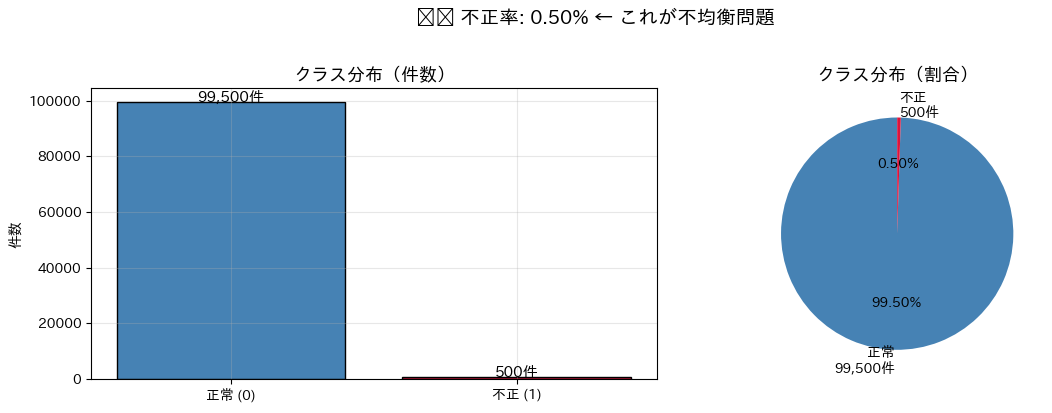


【重要ポイント】
不正率 0.50% のデータで「全部正常と予測」すると...
Accuracy = 99.50% 😱 ← 高く見えるが不正を1件も検知できていない！
→ だから AUC-ROC や Precision-Recall を使う


In [4]:
fraud_counts = df["is_fraud"].value_counts()
fraud_rate = df["is_fraud"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 棒グラフ
axes[0].bar(
    ["正常 (0)", "不正 (1)"], fraud_counts.values,
    color=["steelblue", "crimson"],
    edgecolor="black"
)
axes[0].set_title('クラス分布（件数）', fontsize=13, fontweight='bold')
axes[0].set_ylabel('件数')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 100, f'{v:,}件', ha='center', fontsize=11)

# 円グラフ
axes[1].pie(fraud_counts.values,
            labels=[f'正常\n{fraud_counts[0]:,}件', f'不正\n{fraud_counts[1]:,}件'],
            colors=['steelblue', 'crimson'],
            autopct='%1.2f%%', startangle=90)
axes[1].set_title('クラス分布（割合）', fontsize=13, fontweight='bold')

plt.suptitle(f'⚠️ 不正率: {fraud_rate:.2%} ← これが不均衡問題', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\n【重要ポイント】')
print(f'不正率 {fraud_rate:.2%} のデータで「全部正常と予測」すると...')
print(f'Accuracy = {1-fraud_rate:.2%} 😱 ← 高く見えるが不正を1件も検知できていない！')
print(f'→ だから AUC-ROC や Precision-Recall を使う')

### 🔍 EDA : 正常 vs 不正の特徴比較

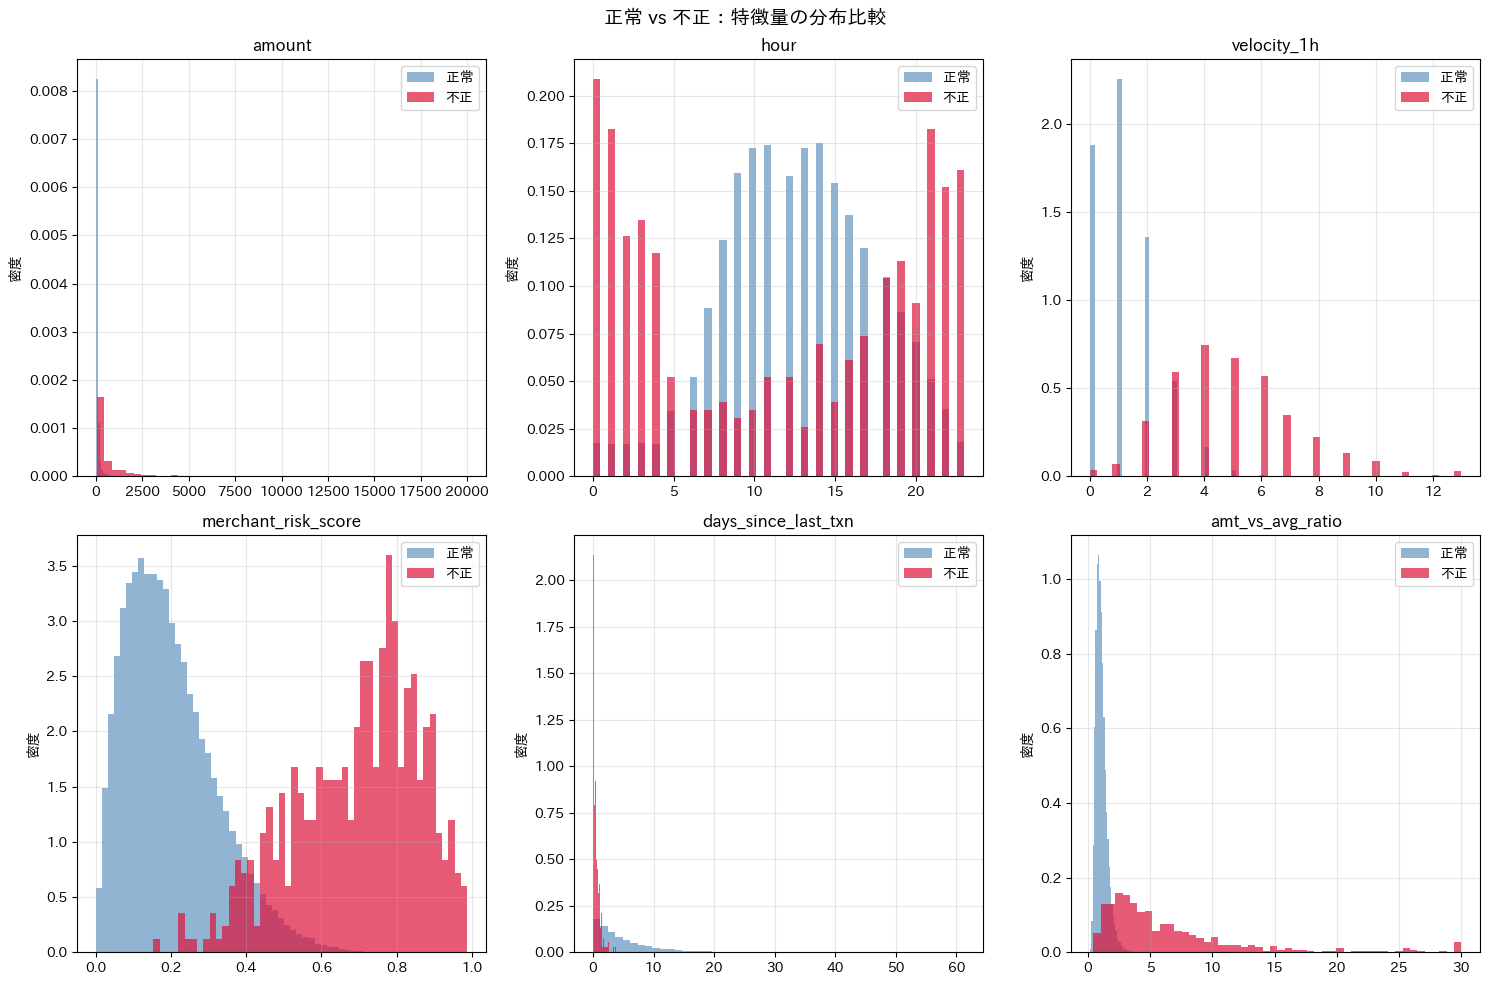


【正常 vs 不正 の平均値比較】


,amount,hour,velocity_1h,merchant_risk_score,days_since_last_txn,amt_vs_avg_ratio
正常 (0),68.261,12.733,1.202,0.200,4.993,1.084
不正 (1),773.185,11.510,4.992,0.694,0.508,6.335


In [6]:
feature_cols_eda = ['amount', 'hour', 'velocity_1h', 'merchant_risk_score',
                    'days_since_last_txn', 'amt_vs_avg_ratio']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols_eda):
    normal = df[df['is_fraud'] == 0][col]
    fraud  = df[df['is_fraud'] == 1][col]

    axes[i].hist(normal, bins=50, alpha=0.6, color='steelblue',
                 density=True, label='正常')
    axes[i].hist(fraud, bins=50, alpha=0.7, color='crimson',
                 density=True, label='不正')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend()
    axes[i].set_ylabel('密度')

plt.suptitle('正常 vs 不正：特徴量の分布比較', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 統計比較表
stats = df.groupby('is_fraud')[feature_cols_eda].mean().round(3)
stats.index = ['正常 (0)', '不正 (1)']
print('\n【正常 vs 不正 の平均値比較】')
stats

---
## STEP 2: 特徴量エンジニアリング

> 💡 **実務では**: ここがモデルの性能を左右する最重要ステップ。ドメイン知識が必須。

In [7]:
def add_features(df):
    df = df.copy()

    # 深夜フラグ（0〜5時, 22〜23時）
    df['is_night'] = df['hour'].apply(lambda h: 1 if h <= 5 or h >= 22 else 0)

    # 高額フラグ（95パーセンタイル超）
    threshold_95 = df['amount'].quantile(0.95)
    df['is_high_amount'] = (df['amount'] > threshold_95).astype(int)

    # 速度 × 金額の交互作用（短時間高頻度＋高額＝危険）
    df['velocity_amount_interaction'] = df['velocity_1h'] * df['amount']

    # リスクスコア × 海外フラグ
    df['foreign_risk'] = df['is_foreign'] * df['merchant_risk_score']

    return df

df = add_features(df)

FEATURE_COLS = [
    'amount', 'hour', 'days_since_last_txn', 'merchant_risk_score',
    'is_foreign', 'velocity_1h', 'velocity_24h', 'amt_vs_avg_ratio',
    'is_night', 'is_high_amount', 'velocity_amount_interaction', 'foreign_risk'
]
TARGET_COL = 'is_fraud'

print(f'✅ 特徴量エンジニアリング完了: {len(FEATURE_COLS)} 特徴量')
print('追加特徴量:', ['is_night', 'is_high_amount', 'velocity_amount_interaction', 'foreign_risk'])

✅ 特徴量エンジニアリング完了: 12 特徴量
追加特徴量: ['is_night', 'is_high_amount', 'velocity_amount_interaction', 'foreign_risk']


---
## STEP 3: 学習/テスト分割 + SMOTE

### ⚠️ 最重要: SMOTE はテストデータに使ってはいけない
```
全データ
  ├── 訓練データ (80%)
  │     └── SMOTE を適用 ← ここだけ
  └── テストデータ (20%)
        └── 実際の不均衡のまま評価 ← 現実に合わせる
```

In [9]:
X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

# 層化サンプリングで分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

# 標準化
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("分割結果:")
print(f"    Train: {len(X_train):,}件  不正率: {y_train.mean():.3%}")
print(f"    Test : {len(X_test):,}件  不正率: {y_test.mean():.3%}")

分割結果:
    Train: 80,000件  不正率: 0.500%
    Test : 20,000件  不正率: 0.500%


SMOTE 結果:
  前: 正常=79,600  不正=400
  後: 正常=79,600  不正=7,960
  不正率: 0.500% → 9.091%


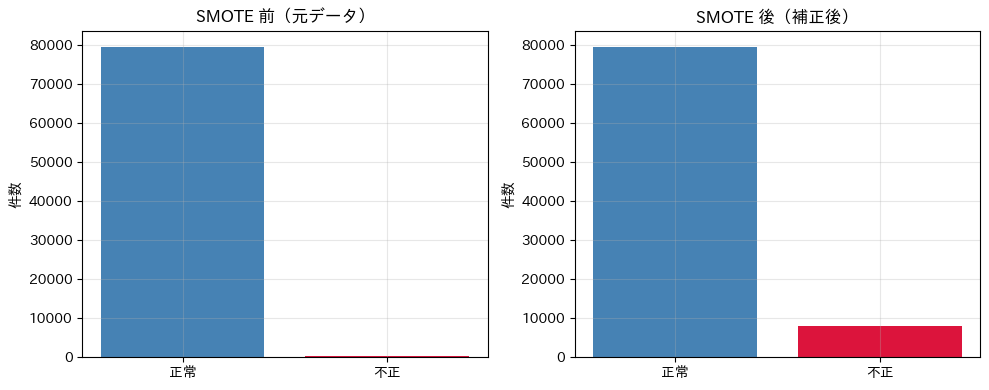

In [11]:
# SMOTE で訓練データの不均衡を補正
smote = SMOTE(
    sampling_strategy=0.1,  # 不正:正常 = 1:10 になるように合成
    random_state=RANDOM_SEED,
    k_neighbors=5
)

X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print('SMOTE 結果:')
print(f'  前: 正常={sum(y_train==0):,}  不正={sum(y_train==1):,}')
print(f'  後: 正常={sum(y_train_res==0):,}  不正={sum(y_train_res==1):,}')
print(f'  不正率: {y_train.mean():.3%} → {y_train_res.mean():.3%}')

# SMOTE 前後の比較
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_data, title in zip(axes,
                             [y_train, y_train_res],
                             ['SMOTE 前（元データ）', 'SMOTE 後（補正後）']):
    vals = pd.Series(y_data).value_counts()
    ax.bar(['正常', '不正'], [vals.get(0,0), vals.get(1,0)],
           color=['steelblue', 'crimson'])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('件数')
plt.tight_layout()
plt.show()

--- 
## STEP4 : XGBoost で学習

In [13]:
# scale_pos_weight を計算
neg = sum(y_train_res == 0)
pos = sum(y_train_res == 1)
spw = neg / pos
print(f"scale_pos_weight = {spw:.2f}")

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_sc, y_test)],
    verbose=100
)

print(f'\n✅ 学習完了（最適ラウンド: {model.best_iteration}）')

scale_pos_weight = 10.00
[0]	validation_0-aucpr:0.72988
[42]	validation_0-aucpr:0.98852

✅ 学習完了（最適ラウンド: 12）


---

## STEP5 : 評価

### なぜ AUC-ROC と PR 曲線をセットで見るか

- **ROC 曲線** : 不正率が低いデータでは楽観的になりやすい
- **RP 曲線** : 不正（少数クラス）に特化した厳しい評価
- -> 両方合わせて判断するのが実務スタンダード

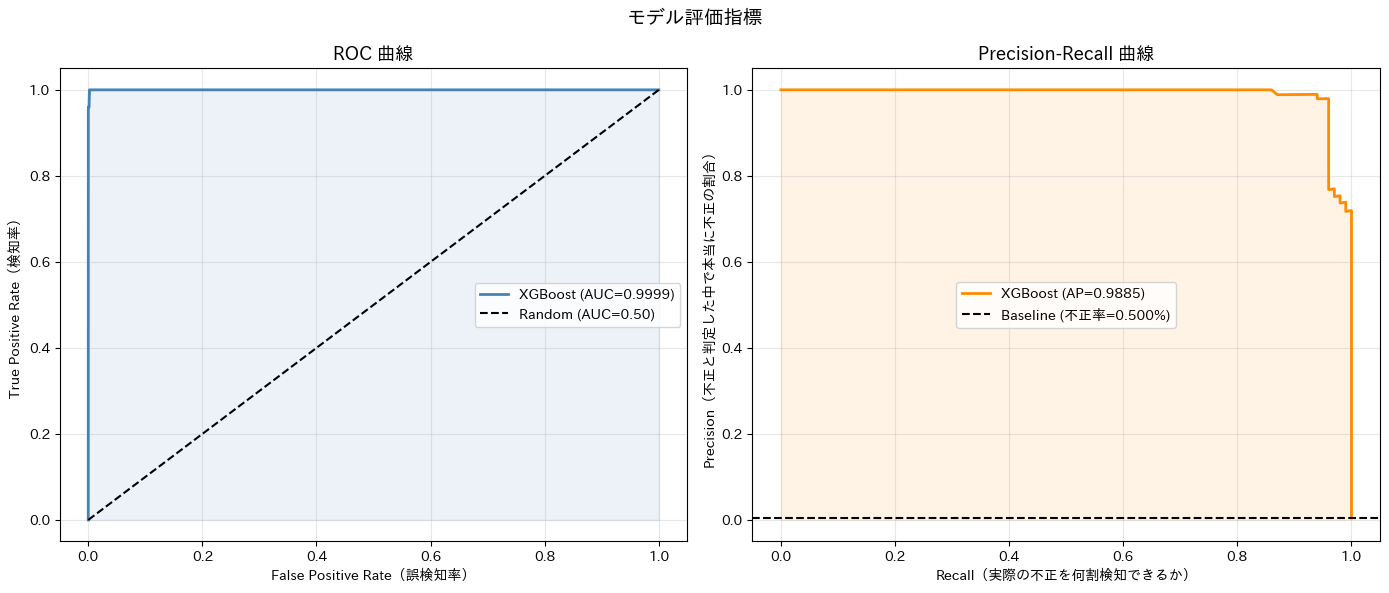

AUC-ROC: 0.9999  |  Average Precision: 0.9885


In [14]:
y_prob = model.predict_proba(X_test_sc)[:, 1]  # 不正確率スコア

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC 曲線
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1],'k--', label='Random (AUC=0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('False Positive Rate（誤検知率）')
axes[0].set_ylabel('True Positive Rate（検知率）')
axes[0].set_title('ROC 曲線', fontsize=13, fontweight='bold')
axes[0].legend()

# PR 曲線
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
baseline = y_test.mean()
axes[1].plot(recall, precision, color='darkorange', lw=2, label=f'XGBoost (AP={ap:.4f})')
axes[1].axhline(y=baseline, color='k', linestyle='--', label=f'Baseline (不正率={baseline:.3%})')
axes[1].fill_between(recall, precision, alpha=0.1, color='darkorange')
axes[1].set_xlabel('Recall（実際の不正を何割検知できるか）')
axes[1].set_ylabel('Precision（不正と判定した中で本当に不正の割合）')
axes[1].set_title('Precision-Recall 曲線', fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('モデル評価指標', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'evaluation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC-ROC: {auc:.4f}  |  Average Precision: {ap:.4f}')

### 閾値（Threshold）の最適化

> 💡 実務では「不正見逃し1件 = 顧客クレーム何件分？」というビジネスコストで決める

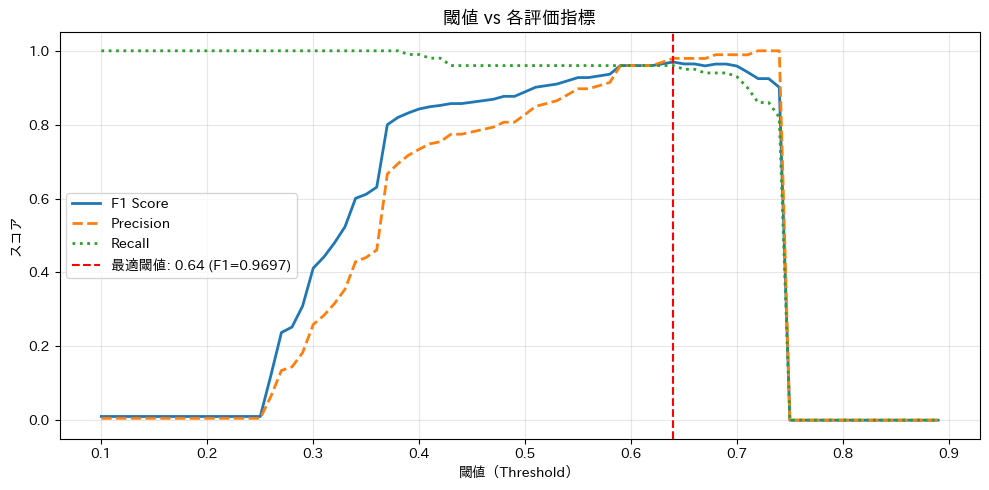


最適閾値: 0.64
  F1=0.9697  Precision=0.9796  Recall=0.9600


In [15]:
thresholds = np.arange(0.1, 0.9, 0.01)
results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    results.append({
        'threshold': t,
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(results)
best = results_df.loc[results_df['f1'].idxmax()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df['threshold'], results_df['f1'],        label='F1 Score',  lw=2)
ax.plot(results_df['threshold'], results_df['precision'], label='Precision', lw=2, linestyle='--')
ax.plot(results_df['threshold'], results_df['recall'],    label='Recall',    lw=2, linestyle=':')
ax.axvline(x=best['threshold'], color='red', linestyle='--',
           label=f"最適閾値: {best['threshold']:.2f} (F1={best['f1']:.4f})")
ax.set_xlabel('閾値（Threshold）')
ax.set_ylabel('スコア')
ax.set_title('閾値 vs 各評価指標', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n最適閾値: {best['threshold']:.2f}")
print(f"  F1={best['f1']:.4f}  Precision={best['precision']:.4f}  Recall={best['recall']:.4f}")

In [23]:
best

f1_score(y_test, model.predict(X_test_sc))
precision_score(y_test, model.predict(X_test_sc))
recall_score(y_test, model.predict(X_test_sc))

0.96

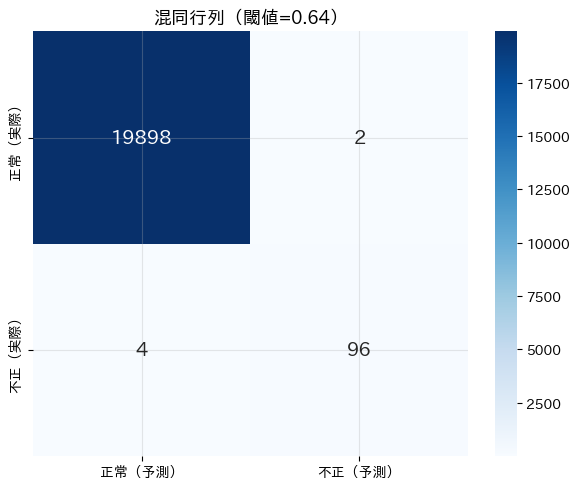

TN=19,898 | FP=2 | FN=4 | TP=96
FP（正常をブロック）= 顧客クレームリスク
FN（不正見逃し）   = 金銭的損失リスク

              precision    recall  f1-score   support

          正常     0.9998    0.9999    0.9998     19900
          不正     0.9796    0.9600    0.9697       100

    accuracy                         0.9997     20000
   macro avg     0.9897    0.9799    0.9848     20000
weighted avg     0.9997    0.9997    0.9997     20000



In [24]:
# 最適閾値で混同行列
best_thresh = best["threshold"]
y_pred = (y_prob >= best_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['正常（予測）', '不正（予測）'],
            yticklabels=['正常（実際）', '不正（実際）'],
            annot_kws={'size': 14})
ax.set_title(f'混同行列（閾値={best_thresh:.2f}）', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}')
print(f'FP（正常をブロック）= 顧客クレームリスク')
print(f'FN（不正見逃し）   = 金銭的損失リスク')
print()
print(classification_report(y_test, y_pred, target_names=['正常', '不正'], digits=4))

---

## STEP6 : SHAP による説明可能AI

### 「なぜこの取引を不正と判定したか」を説明できるようにする

> 💡 実務での重要性 : 金融機関では規制当局・顧客への説明責任が法的に求められる

In [25]:
# SHAP Explainer の作成
print("SHAP値を計算中 (少々お待ちください) ...")
sample_idx = np.random.choice(len(X_test_sc), size=2000, replace=False)
#X_sample = X_test_sc[sample_idx]
X_sample = X_test_sc.copy()
#y_sample = y_test[sample_idx]
y_sample = y_test.copy()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
print('✅ 計算完了')

SHAP値を計算中 (少々お待ちください) ...
✅ 計算完了


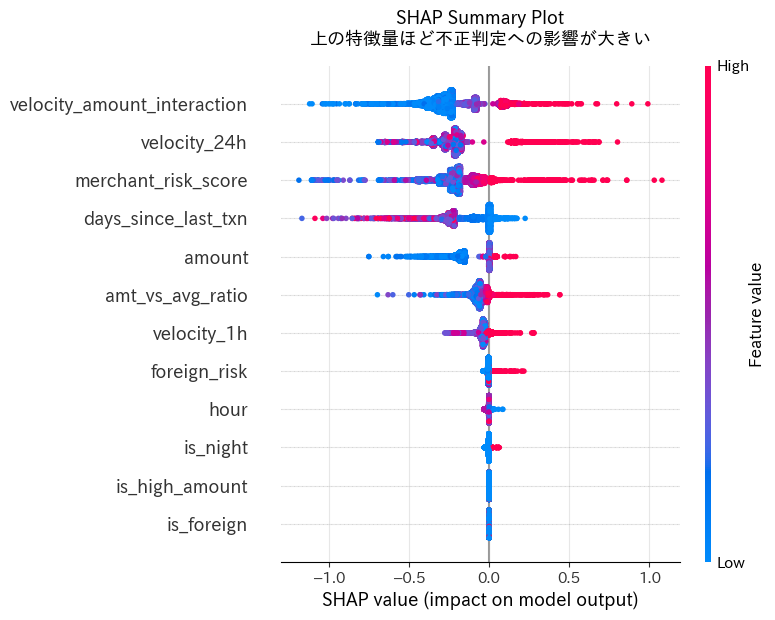

In [26]:
# Summary Plot（Beeswarm）
# 読み方:
#  縦軸: 特徴量（上ほど影響大）
#  横軸: SHAP値（右=不正方向、左=正常方向）
#  色  : 特徴量の値（赤=高い、青=低い）

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS,
                  show=False, max_display=12)
plt.title('SHAP Summary Plot\n上の特徴量ほど不正判定への影響が大きい',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

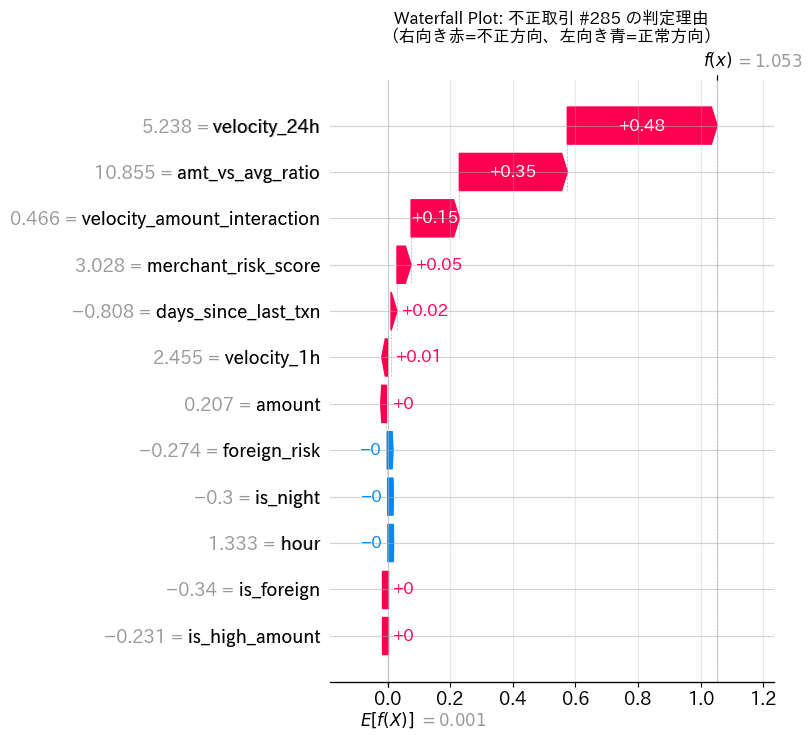

【この取引の特徴量値】
  amount                             : 0.2067
  hour                               : 1.3333
  days_since_last_txn                : -0.8078
  merchant_risk_score                : 3.0281
  is_foreign                         : -0.3401
  velocity_1h                        : 2.4552
  velocity_24h                       : 5.2381
  amt_vs_avg_ratio                   : 10.8555
  is_night                           : -0.2998
  is_high_amount                     : -0.2314
  velocity_amount_interaction        : 0.4656
  foreign_risk                       : -0.2743


In [27]:
# Waterfall Plot : 1件の取引の判定理由を詳細説明
# 実際の不正取引を1件選ぶ
fraud_in_sample = np.where(y_sample == 1)[0]
case_idx = fraud_in_sample[0]

explanation = shap.Explanation(
    values=shap_values[case_idx],
    base_values=explainer.expected_value,
    data=X_sample[case_idx],
    feature_names=FEATURE_COLS
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(f'Waterfall Plot: 不正取引 #{case_idx} の判定理由\n（右向き赤=不正方向、左向き青=正常方向）',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print('【この取引の特徴量値】')
for feat, val in zip(FEATURE_COLS, X_sample[case_idx]):
    print(f'  {feat:35s}: {val:.4f}')

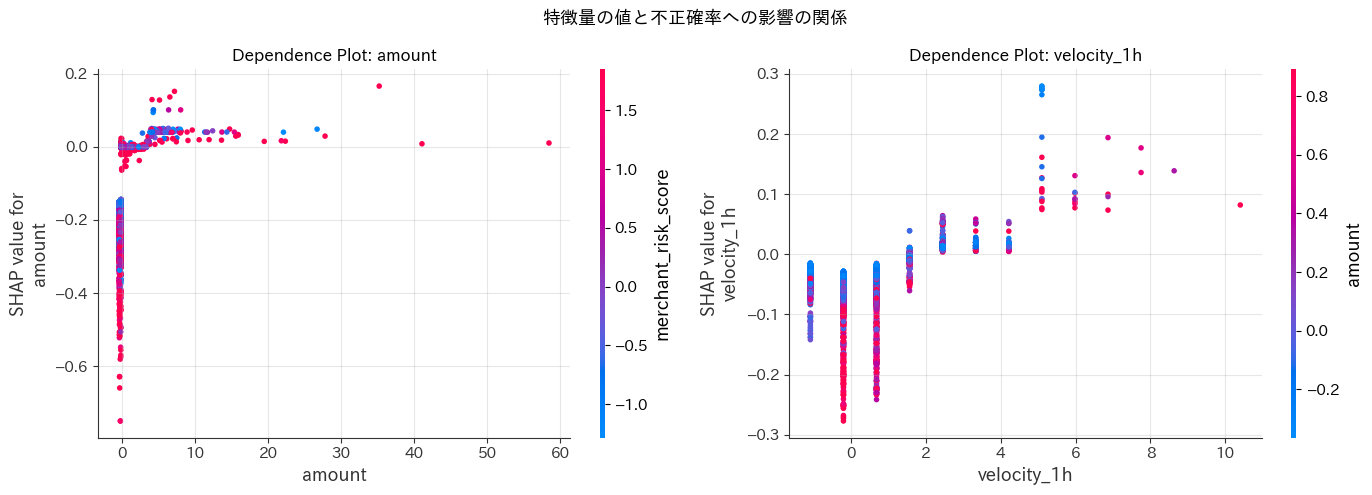

In [32]:
# Dependence Plot: 特定特徴量と SHAP値の関係
# 「取引金額が高くなると、不正確率はどう変化するか」を可視化

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, ['amount', 'velocity_1h']):
    feat_idx = FEATURE_COLS.index(feat)
    shap.dependence_plot(feat_idx, shap_values, X_sample,
                         feature_names=FEATURE_COLS, ax=ax, show=False)
    ax.set_title(f'Dependence Plot: {feat}', fontsize=12, fontweight='bold')

plt.suptitle('特徴量の値と不正確率への影響の関係', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## まとめ: 実務で使えるチェックリスト

| チェック項目 | 理由 |
|-------------|------|
| ✅ 不正率を確認した | 不均衡の程度を把握 |
| ✅ 層化サンプリングで分割した | 不正率を train/test で均等に |
| ✅ SMOTE を train のみに適用した | Data Leak 防止 |
| ✅ Accuracy は使わなかった | 不均衡データでは無意味 |
| ✅ AUC-ROC と PR 曲線を両方確認した | 異なる側面からの評価 |
| ✅ 閾値をビジネスコストで調整した | デフォルト 0.5 は最適とは限らない |
| ✅ SHAP で説明可能にした | 規制対応・顧客説明責任 |

In [34]:
# モデルと前処理を保存（本番運用を想定）
joblib.dump(model, OUTPUT_DIR / 'model_xgboost.pkl')
joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
joblib.dump(FEATURE_COLS, OUTPUT_DIR / 'feature_cols.pkl')
np.save(OUTPUT_DIR / 'X_test.npy', X_test_sc)
np.save(OUTPUT_DIR / 'y_test.npy', y_test)

print('💾 保存完了:')
for f in sorted(OUTPUT_DIR.glob('*')):
    print(f'   {f}')

💾 保存完了:
   ../outputs/X_test.npy
   ../outputs/confusion_matrix.png
   ../outputs/evaluation_curves.png
   ../outputs/feature_cols.pkl
   ../outputs/model_xgboost.pkl
   ../outputs/pr_curve.png
   ../outputs/roc_curve.png
   ../outputs/scaler.pkl
   ../outputs/shap_dependence.png
   ../outputs/shap_dependence_amount.png
   ../outputs/shap_dependence_velocity_1h.png
   ../outputs/shap_importance_bar.png
   ../outputs/shap_summary.png
   ../outputs/shap_waterfall.png
   ../outputs/shap_waterfall_sample.png
   ../outputs/shape_summary.png
   ../outputs/y_test.npy
